In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import polyphase as phase
import numpy as np
import math as mt
import pandas as pd
import csv

In [18]:
def load_database(filename):
    with open(filename, mode='r', newline='') as file:
        reader = csv.DictReader(file)
        return {row['Solvent'].strip().lower(): row for row in reader}

In [47]:
A = load_database('Green_Solvent_PBTTT_PMMA_PS.csv')

In [20]:
solvents = list(A.keys())
#solvents = np.delete(solvents, [9, 10, 11])  # remove useless rows


hansen_s = np.array([
    [float(A[s]['dD (MPa^0.5)']), float(A[s]['dP (MPa^0.5)']), float(A[s]['dH (MPa^0.5)']),float(A[s]['Vm (cm3/mol)'])]
    for s in solvents])

In [21]:
T = 298.15 # K
R = 8.314 # J/(mol*K)

In [22]:
Polymer = 'pmma'
Dopant = 'ps'


V_d = float(A[Dopant]['Vm (cm3/mol)']) # cm^3/mol
V_p = float(A[Polymer]['Vm (cm3/mol)']) # cm^3/mol

dD_d = float(A[Dopant]['dD (MPa^0.5)']) # MPa^1/2
dP_d = float(A[Dopant]['dP (MPa^0.5)']) # MPa^1/2
dH_d = float(A[Dopant]['dH (MPa^0.5)']) # MPa^1/2

dD_p = float(A[Polymer]['dD (MPa^0.5)']) # MPa^1/2
dP_p = float(A[Polymer]['dP (MPa^0.5)']) # MPa^1/2
dH_p = float(A[Polymer]['dH (MPa^0.5)']) # MPa^1/2

In [23]:
n = len(hansen_s) 

Radius = np.zeros((n, 3))
N = np.zeros((n, 3))
X = np.zeros((n, 3))
X_cr = np.zeros((n, 3))

for i in range(n):
    Radius[i, 0] = mt.sqrt(4*(dD_p - dD_d)**2 + (dP_p - dP_d)**2 + (dH_p - dH_d)**2) # polymer1 vs dopant2
    Radius[i, 1] = mt.sqrt(4*(dD_p - hansen_s[i,0])**2 + (dP_p - hansen_s[i,1])**2 + (dH_p - hansen_s[i,2])**2)  # polymer1 vs solvent3 
    Radius[i, 2] = mt.sqrt(4*(dD_d - hansen_s[i,0])**2 + (dP_d - hansen_s[i,1])**2 + (dH_d - hansen_s[i,2])**2)  # dopant2 vs solvent3 
    
    #N[i, 0] = V_p / hansen_s[i, 0] # polymer vs solvent
    #N[i, 1] = V_d / hansen_s[i, 0] # dopant vs solvent
    #N[i, 2] = 1 # solvent vs solvent

    N[i, 0] = 1000 # polymer vs solvent
    N[i, 1] = 3500 # dopant vs solvent
    N[i, 2] = 1 # solvent vs solvent

    X[i, 0] = (hansen_s[i,3] * Radius[i,0]**2 / (4*R*T)) # polymer vs dopant
    X[i, 1] = (hansen_s[i,3] * Radius[i,1]**2 / (4*R*T)) + 0.34 # polymer vs solvent
    X[i, 2] = (hansen_s[i,3] * Radius[i,2]**2 / (4*R*T)) + 0.34 # dopant vs solvent
    
    X_cr[i, 0] = 1/2 * (1/mt.sqrt(N[i,0]) + 1/mt.sqrt(N[i,1]))**2 # polymer vs dopant
    X_cr[i, 1] = 1/2 * (1/mt.sqrt(N[i,0]) + 1/mt.sqrt(N[i,2]))**2 # polymer vs solvent
    X_cr[i, 2] = 1/2 * (1/mt.sqrt(N[i,2]) + 1/mt.sqrt(N[i,1]))**2 # dopant vs solvent

In [49]:
# 'dtype=object' allows the array to hold strings and numbers simultaneously
Crit = np.zeros((n, 5), dtype=object)

for i in range(n):
    for j in range(3):
        if X[i, j] >= X_cr[i, j]:
            Crit[i, j] = 0
        else:
            Crit[i, j] = 1
Crit[:, 0] = [str(A[s]['Solvent']) for s in solvents]
Crit[:,3] = X[:,1] - X_cr[:,1]
Crit[:,4] = X[:,2] - X_cr[:,2]

In [25]:
# 1. Create a list of column names for clarity
column_names = ['Solvent', 'PMMA Sol', 'PS Sol', 'X_13 - X_cr', 'X_23 - X_cr']

# 2. Convert your 'Crit' array into a DataFrame
df = pd.DataFrame(Crit, columns=column_names)

# 3. Save to CSV
# 'index=False' prevents Pandas from adding an extra column for row numbers
file_name = f"{Polymer}_{Dopant}_{N[1, 0]}_{N[1, 1]}_{N[1, 2]}.csv"
df.to_csv(file_name, index=False)

File saved successfully!


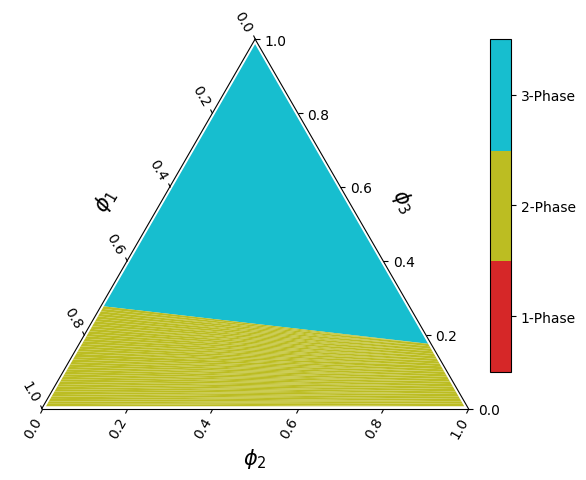

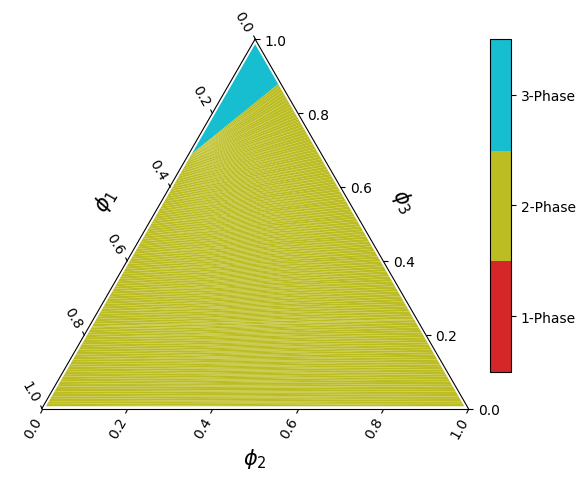

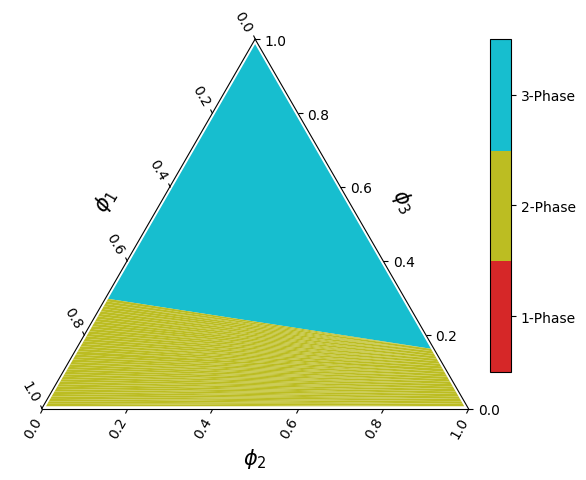

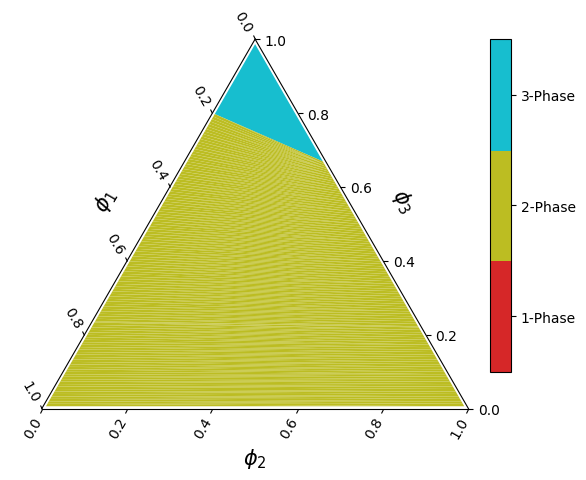

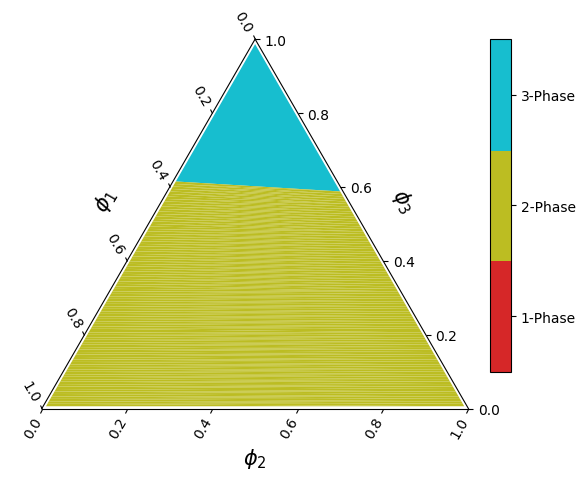

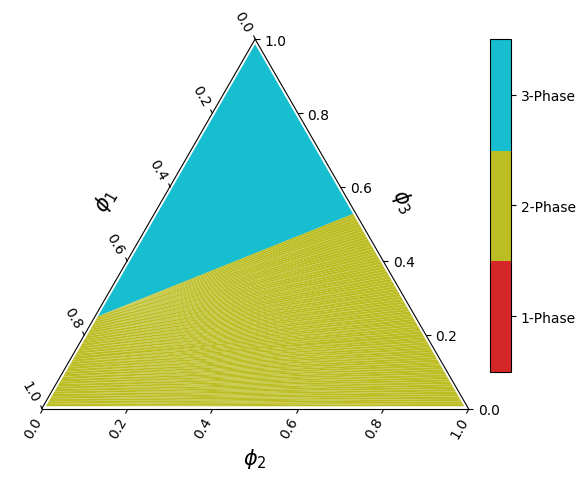

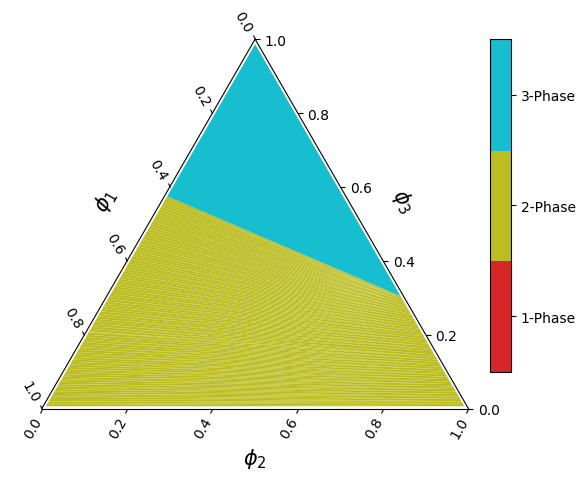

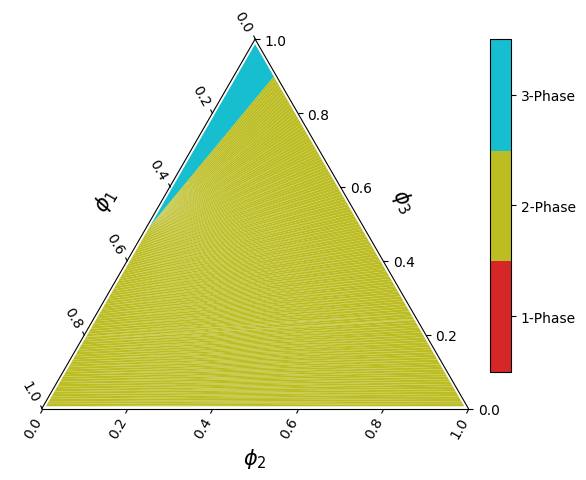

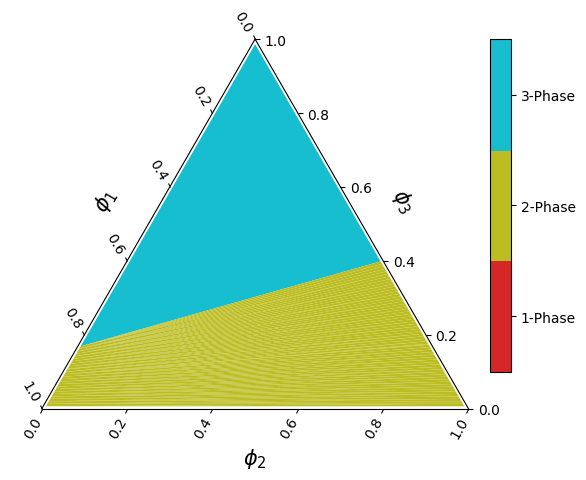

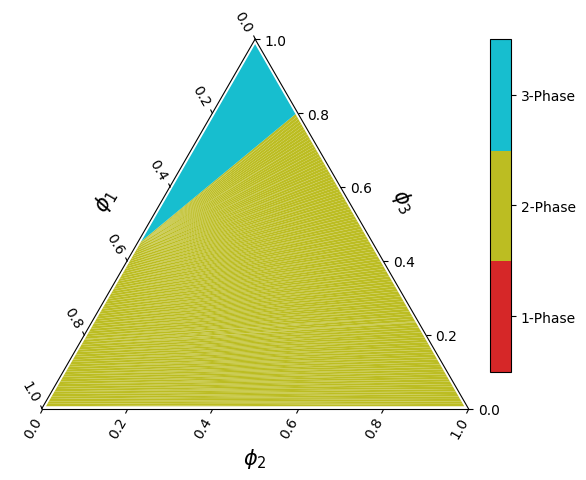

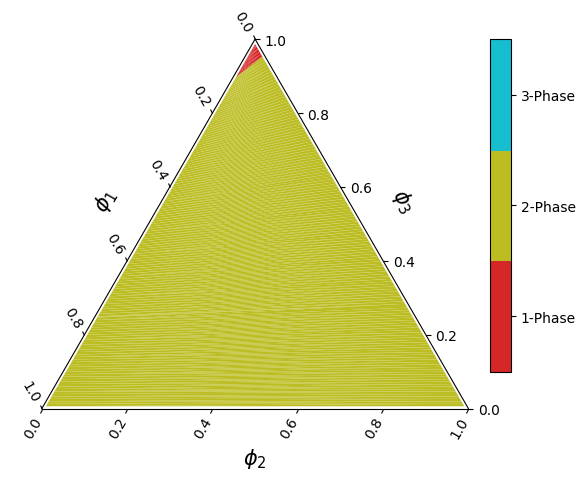

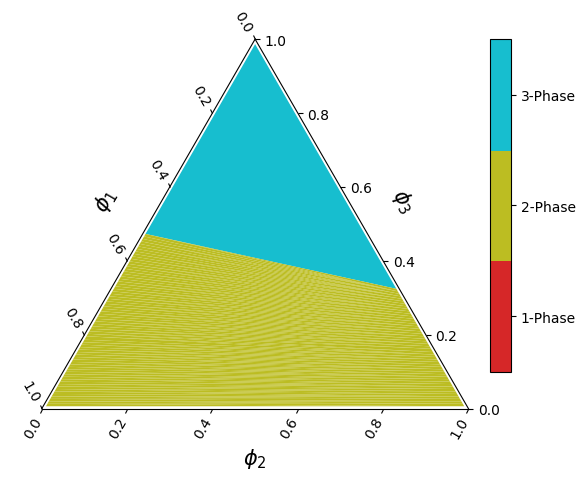

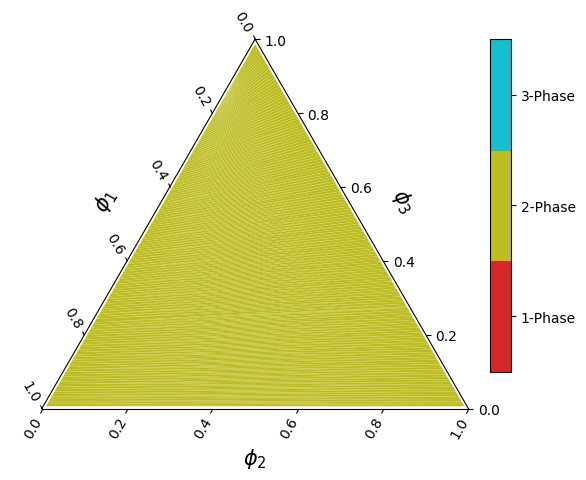

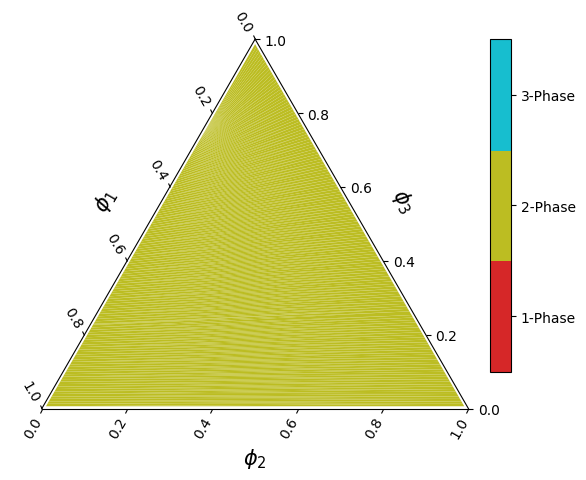

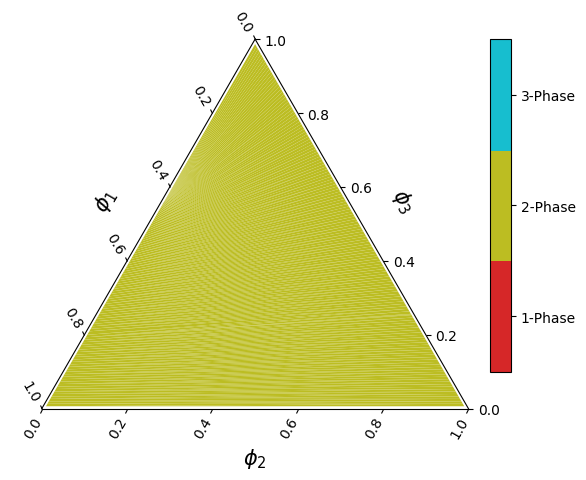

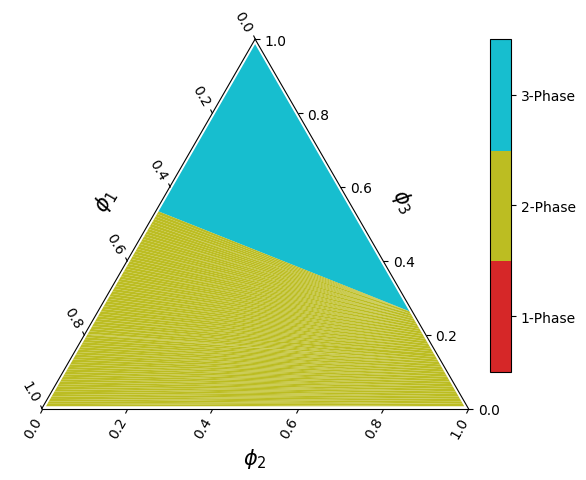

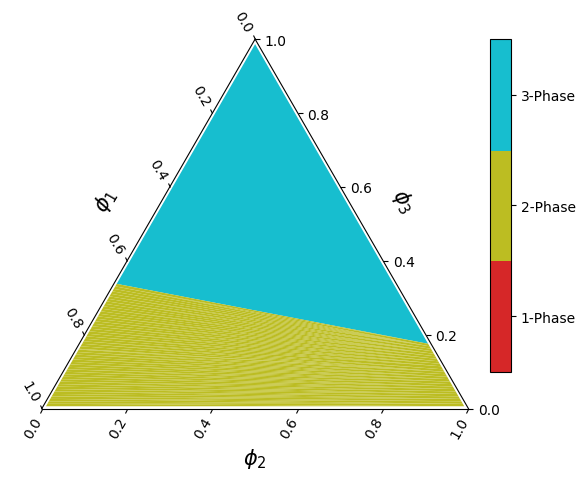

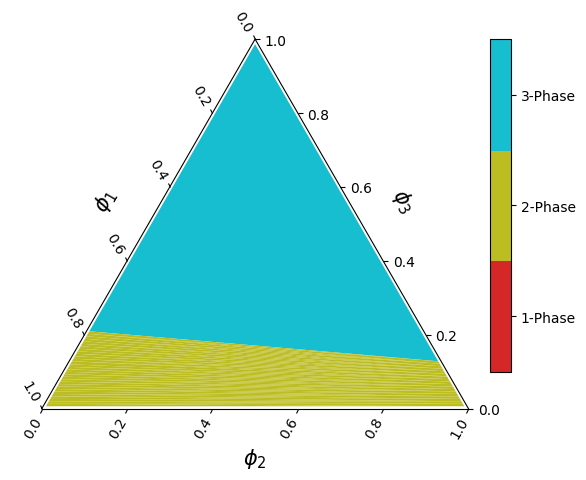

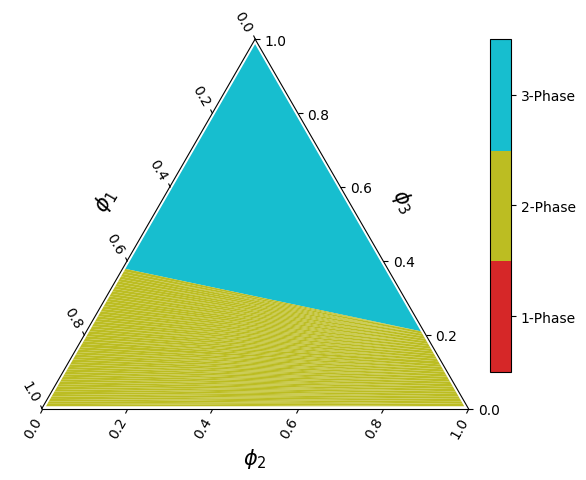

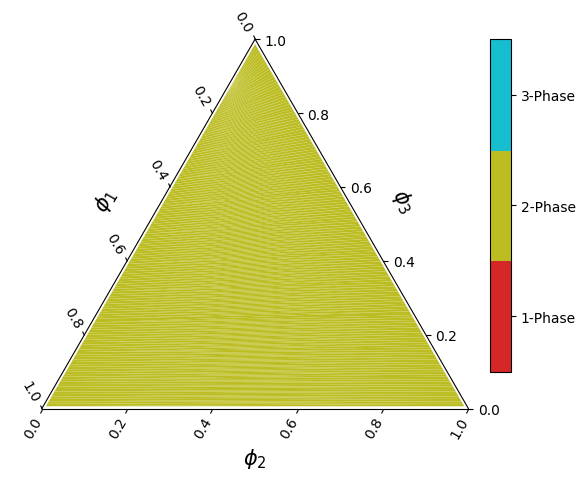

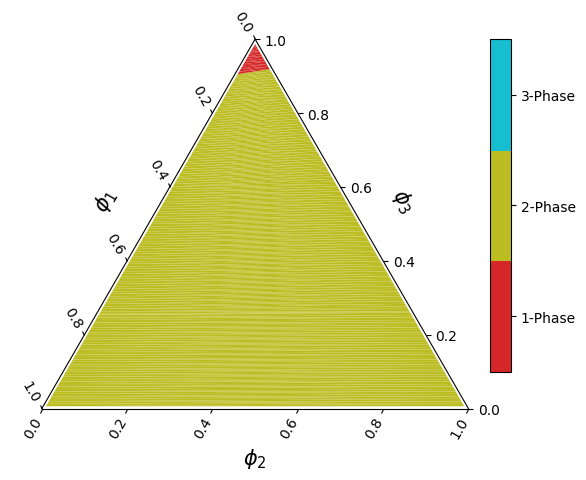

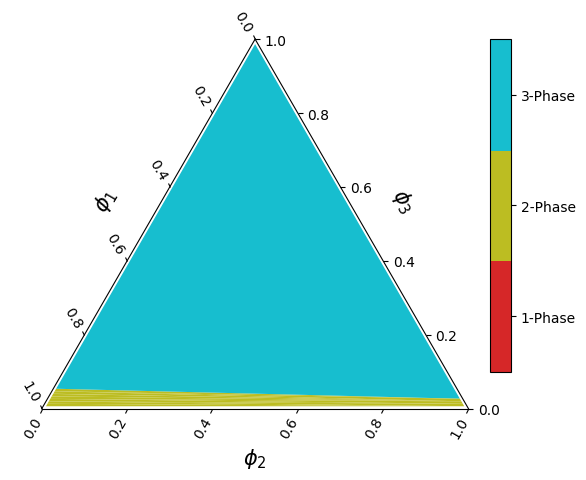

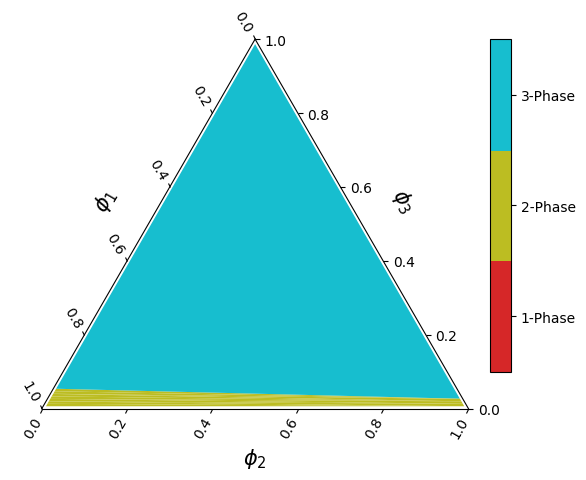

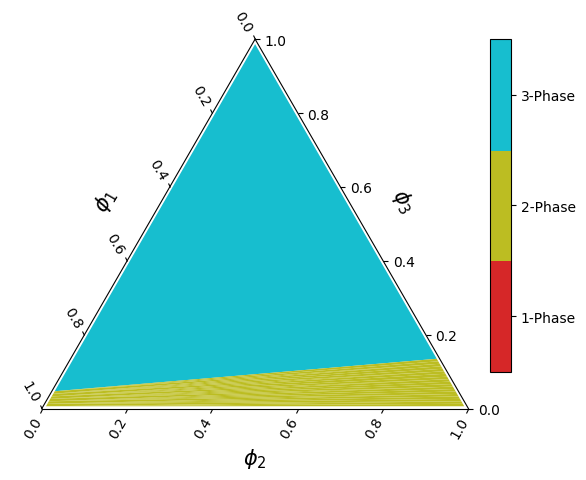

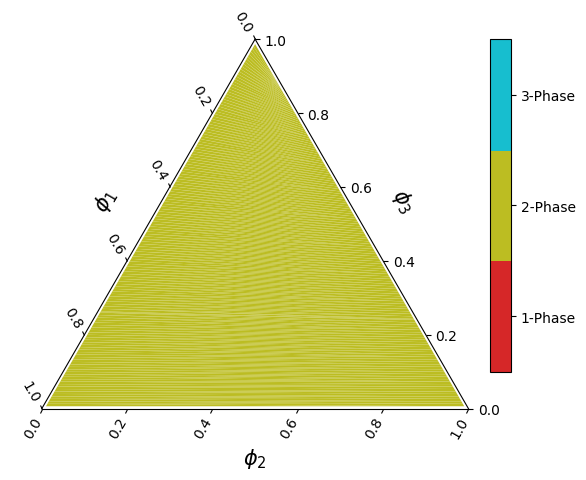

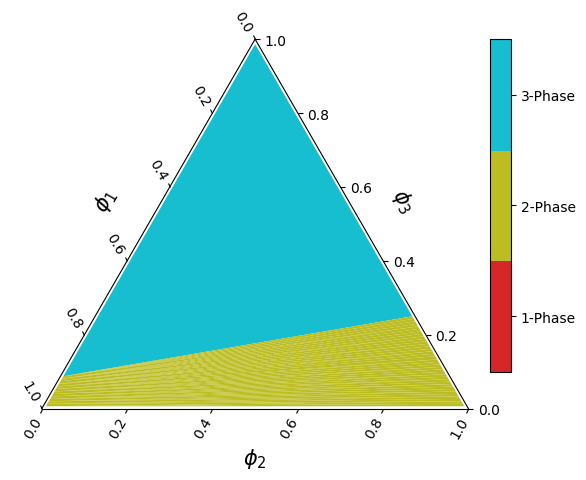

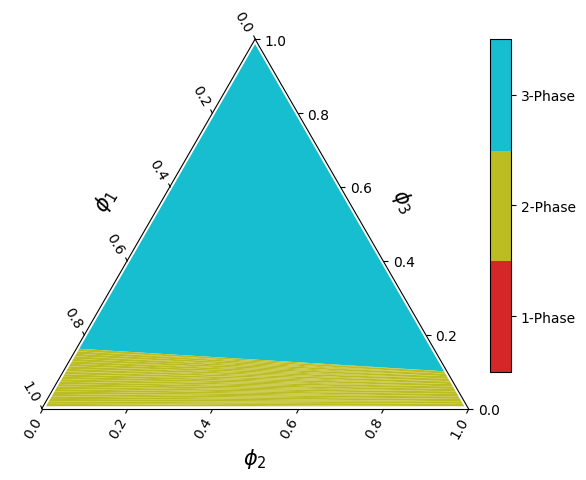

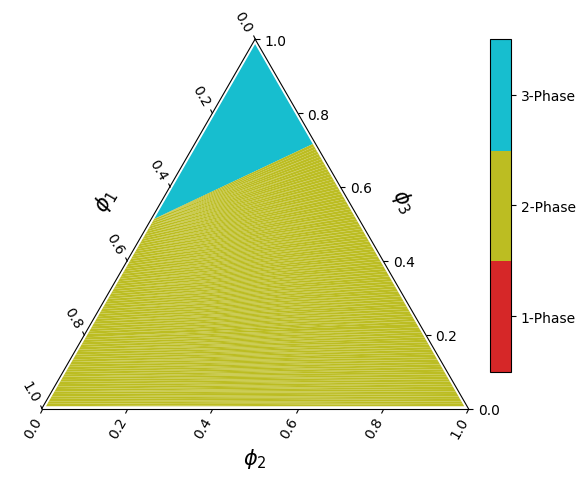

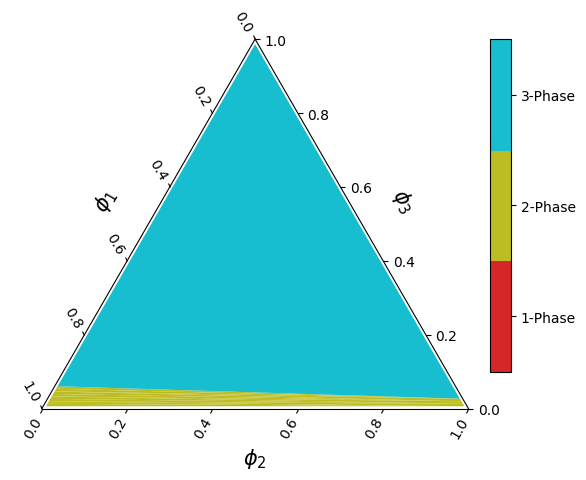

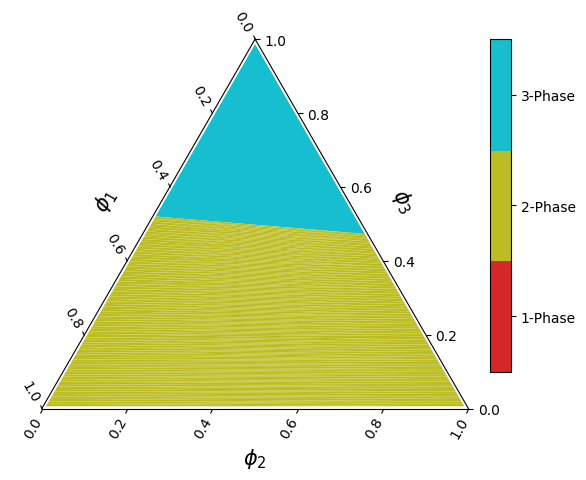

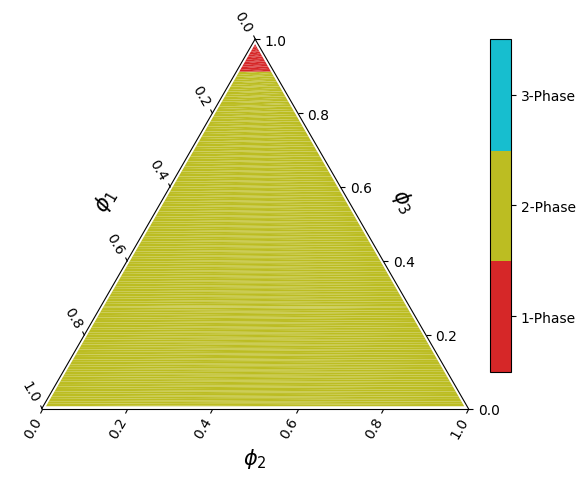

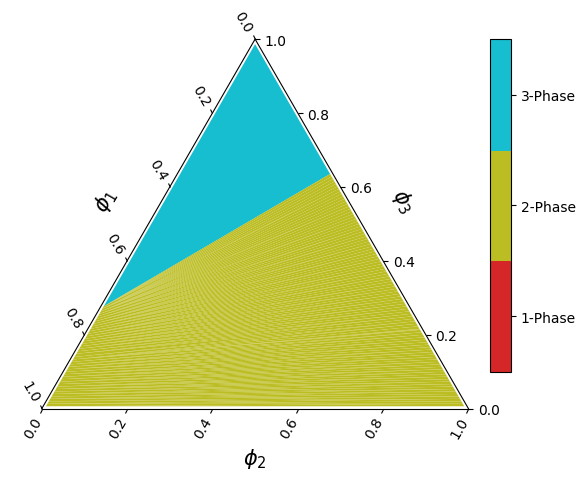

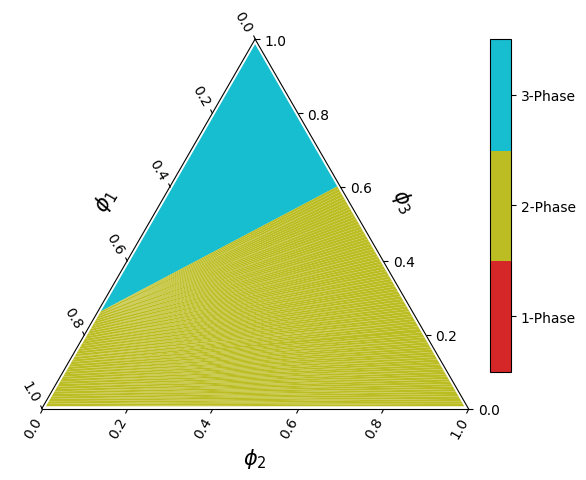

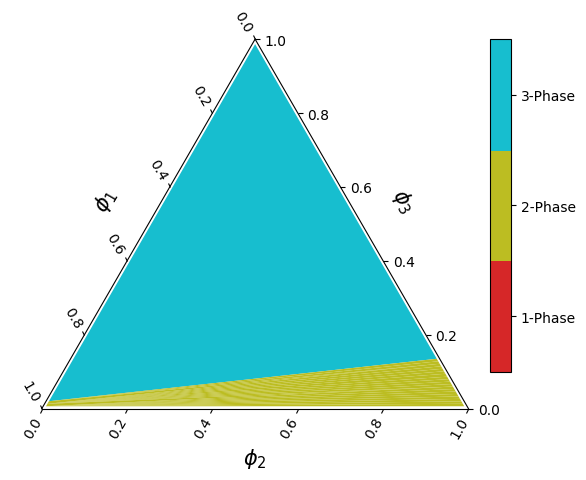

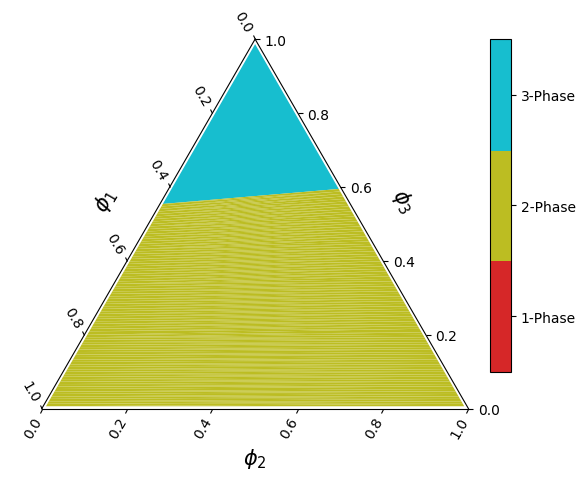

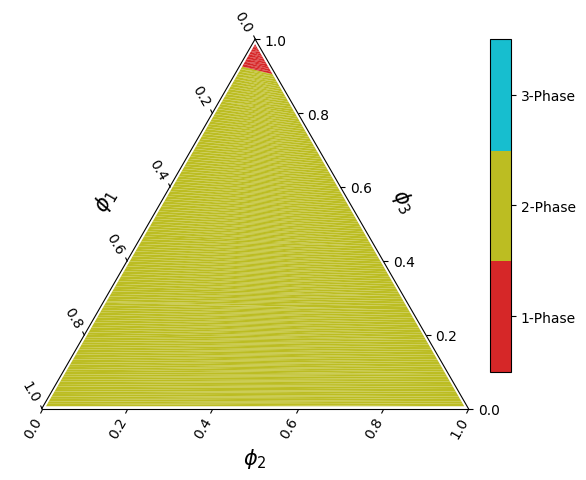

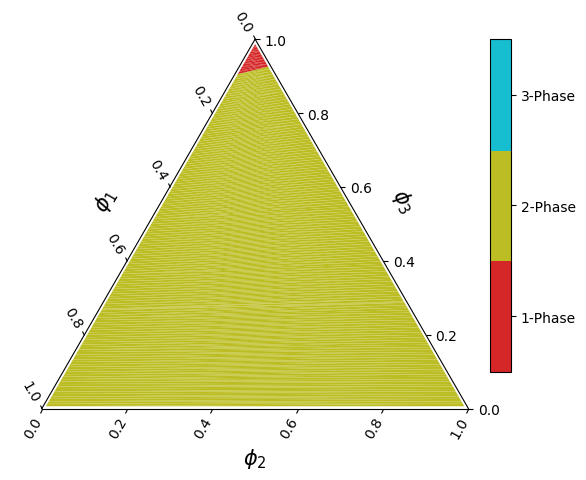

In [26]:
import matplotlib.pyplot as plt

B = list(A.keys())
np.delete(B, [len(B)-2,len(B)-1])

engines = []
id = 0;
for i in range(n):
    M = N[i, :]
    chi = X[i, :]
    f = lambda x, M=M, chi=chi: phase.flory_huggins(x, M, chi) 
    engine = phase.PHASE(f, 150, 3)
    engine.compute(use_parallel=False, verbose=False, lift_label=True) 
    engine.plot(filename=f"{B[id]}.png")
    id = id + 1